In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Descripción del dataset de cultivos ["Agriculture Crop Yield"](https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield):
- **Region**: Región geográfica donde crece el cultivo (North, East, South, West).

- **Soil_Type**: Tipo de suelo donde el cultivo es plantado (Clay, Sandy, Loam, Silt, Peaty, Chalky).

- **Crop**: Tipo de cultivo que crece (Wheat, Rice, Maize, Barley, Soybean, Cotton).

- **Rainfall_mm**: La cantidad de lluvia recibida en milímetros durante la etapa de crecimiento del cultivo.

- **Temperature_Celsius**: La temperatura promedio durante el período de crecimiendo, medido en grados Celsius.

- **Fertilizer_Used**: Indica si se aplicó fertilizador (True = Si, False = No).

- **Irrigation_Used**: Indica si se usó riego durante el período de crecimiento (True = Si, False = No).

- **Weather_Condition**: La condición climática predominante durante la temporada de crecimiento. (Sunny, Rainy, Cloudy).

- **Days_to_Harvest**: El número de días que tarda la cosecha en ser cosechada después de la siembra.

- **Yield_tons_per_hectare**: El rendimiento total del cultivo producido, medido en toneladas por hectárea.



In [135]:
data = pd.read_csv('./data/crop_yield.csv')
data

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


In [136]:
target = 'Barley'
data = data[data['Crop'] == target ]
data = data.drop(columns=['Crop'])


In [137]:
# transformación de variables categóricas a numéricas
# utilizaremos One Hot Encoding para la variable 'Weather_Condition'

data = pd.get_dummies(
    data,
    dtype=int,
    columns=['Weather_Condition'],
    drop_first=False
)

data = pd.get_dummies(
    data,
    dtype=int,
    columns=['Soil_Type'],
    drop_first=False
)

data = pd.get_dummies(
    data,
    dtype=int,
    columns=['Region'],
    drop_first=False
)

data['Fertilizer_Used'] = data['Fertilizer_Used'].astype(int)
data['Irrigation_Used'] = data['Irrigation_Used'].astype(int)

In [138]:
data

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Region_East,Region_North,Region_South,Region_West
2,147.998025,29.794042,0,0,106,1.127443,0,0,1,0,0,1,0,0,0,0,1,0,0
13,929.123735,29.677303,0,1,134,6.493031,0,1,0,0,1,0,0,0,0,1,0,0,0
14,621.778388,26.843173,1,0,77,4.573219,0,1,0,0,0,0,1,0,0,0,1,0,0
18,977.259083,17.604100,0,1,93,5.778099,0,0,1,0,0,0,0,1,0,0,1,0,0
21,183.939698,34.227923,1,0,99,3.017924,1,0,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999977,888.925604,30.417805,1,0,116,6.861778,0,0,1,0,0,0,0,1,0,1,0,0,0
999981,771.012584,15.115510,0,0,137,4.576073,0,1,0,0,0,0,0,1,0,0,1,0,0
999988,394.413067,22.239362,0,1,129,2.950857,0,1,0,0,1,0,0,0,0,1,0,0,0
999989,186.698773,24.926246,0,0,149,1.438205,0,0,1,0,0,1,0,0,0,0,1,0,0


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Region_East,Region_North,Region_South,Region_West
0,897.077239,27.676966,0,1,122,6.555816,1,0,0,0,0,0,0,1,0,0,0,0,1
11,145.300681,19.755535,1,1,141,4.367612,1,0,0,0,0,0,0,1,0,1,0,0,0
12,607.150252,15.562163,1,1,136,6.525186,0,0,1,0,0,0,1,0,0,0,0,1,0
17,416.898632,23.190810,1,1,95,4.858924,0,0,1,0,1,0,0,0,0,0,1,0,0
20,990.267439,24.072052,0,1,110,6.187396,0,0,1,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999973,217.387025,27.306320,0,0,137,1.001849,1,0,0,0,0,0,1,0,0,0,1,0,0
999974,528.002127,37.384126,0,1,62,3.571633,0,1,0,0,0,1,0,0,0,0,0,1,0
999976,959.604272,32.334733,0,0,109,5.097432,1,0,0,1,0,0,0,0,0,0,1,0,0
999979,315.605610,30.119779,1,1,118,4.802915,1,0,0,0,0,1,0,0,0,0,0,1,0


# EDA

In [27]:
# plt.figure(figsize=(5, 3))
# sns.countplot(data=data, x='Crop', hue='Crop')
# plt.plot()

[]

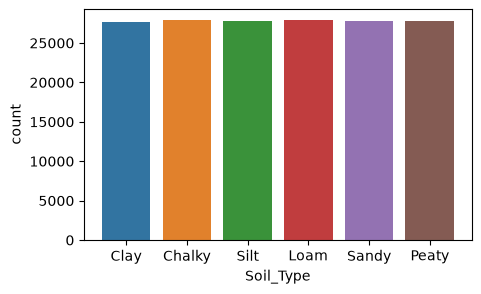

In [28]:
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x='Soil_Type', hue='Soil_Type')
plt.plot()

[]

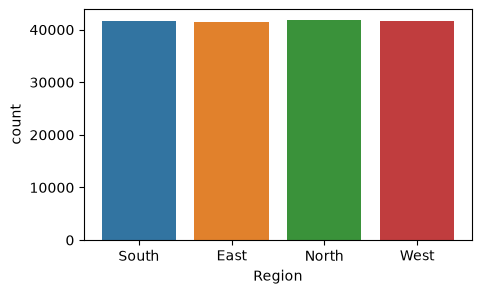

In [29]:
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x='Region', hue='Region')
plt.plot()

[]

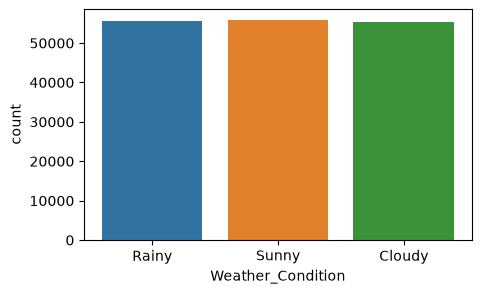

In [30]:
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x='Weather_Condition', hue='Weather_Condition')
plt.plot()

[]

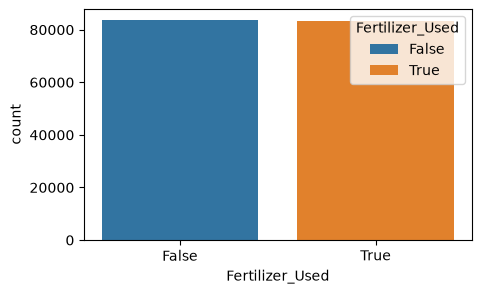

In [31]:
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x='Fertilizer_Used', hue='Fertilizer_Used')
plt.plot()

[]

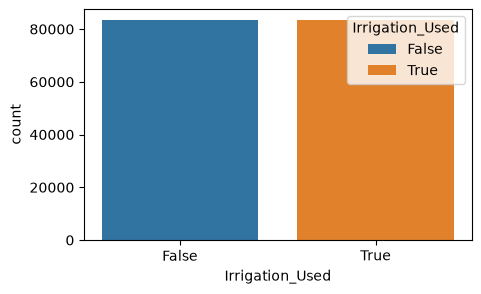

In [32]:
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x='Irrigation_Used', hue='Irrigation_Used')
plt.plot()

In [60]:
data.describe()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Weather_Condition_Rainy,Weather_Condition_Sunny
count,166824.000000,166824.000000,166824.000000,166824.000000,166824.000000,166824.000000,166824.000000,166824.000000
mean,549.195094,27.477555,0.498453,0.499958,104.538927,4.641387,0.333663,0.334712
std,259.904451,7.217551,0.499999,0.500001,25.952050,1.696023,0.471522,0.471891
min,100.006823,15.000196,0.000000,0.000000,60.000000,-0.875193,0.000000,0.000000
25%,323.726771,21.223494,0.000000,0.000000,82.000000,3.409851,0.000000,0.000000
50%,549.672583,27.471440,0.000000,0.000000,105.000000,4.642647,0.000000,0.000000
75%,774.026381,33.709365,1.000000,1.000000,127.000000,5.870040,1.000000,1.000000
max,999.998098,39.999933,1.000000,1.000000,149.000000,9.952983,1.000000,1.000000


In [59]:
# Cantidad de NAs
data.isna().sum()

Region                     0
Soil_Type                  0
Rainfall_mm                0
Temperature_Celsius        0
Fertilizer_Used            0
Irrigation_Used            0
Days_to_Harvest            0
Yield_tons_per_hectare     0
Weather_Condition_Rainy    0
Weather_Condition_Sunny    0
dtype: int64

In [35]:
# categorical = ['Crop', 'Region', 'Soil_Type', 'Weather_Condition']
# for i in categorical:
#     print(f'----------------------------------')
#     print(data[i].value_counts())

ValueError: Could not interpret value `Crop` for `x`. An entry with this name does not appear in `data`.

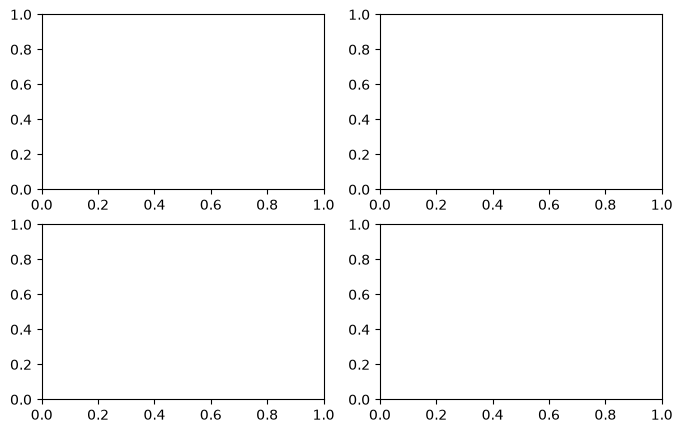

In [36]:
categorical = ['Crop', 'Soil_Type', 'Region', 'Weather_Condition']

fig, axes = plt.subplots(2, 2, figsize=(8, 5))

for ax, col in zip(axes.flatten(), categorical):
    sns.countplot(data=data, x=col, hue=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [61]:
cat_features = ['Crop', 'Soil_Type', 'Region', 'Weather_Condition']
bin_features = ['Fertilizer_Used', 'Irrigation_Used']
num_features = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare']

In [82]:
df = data.drop(columns=['Region'])

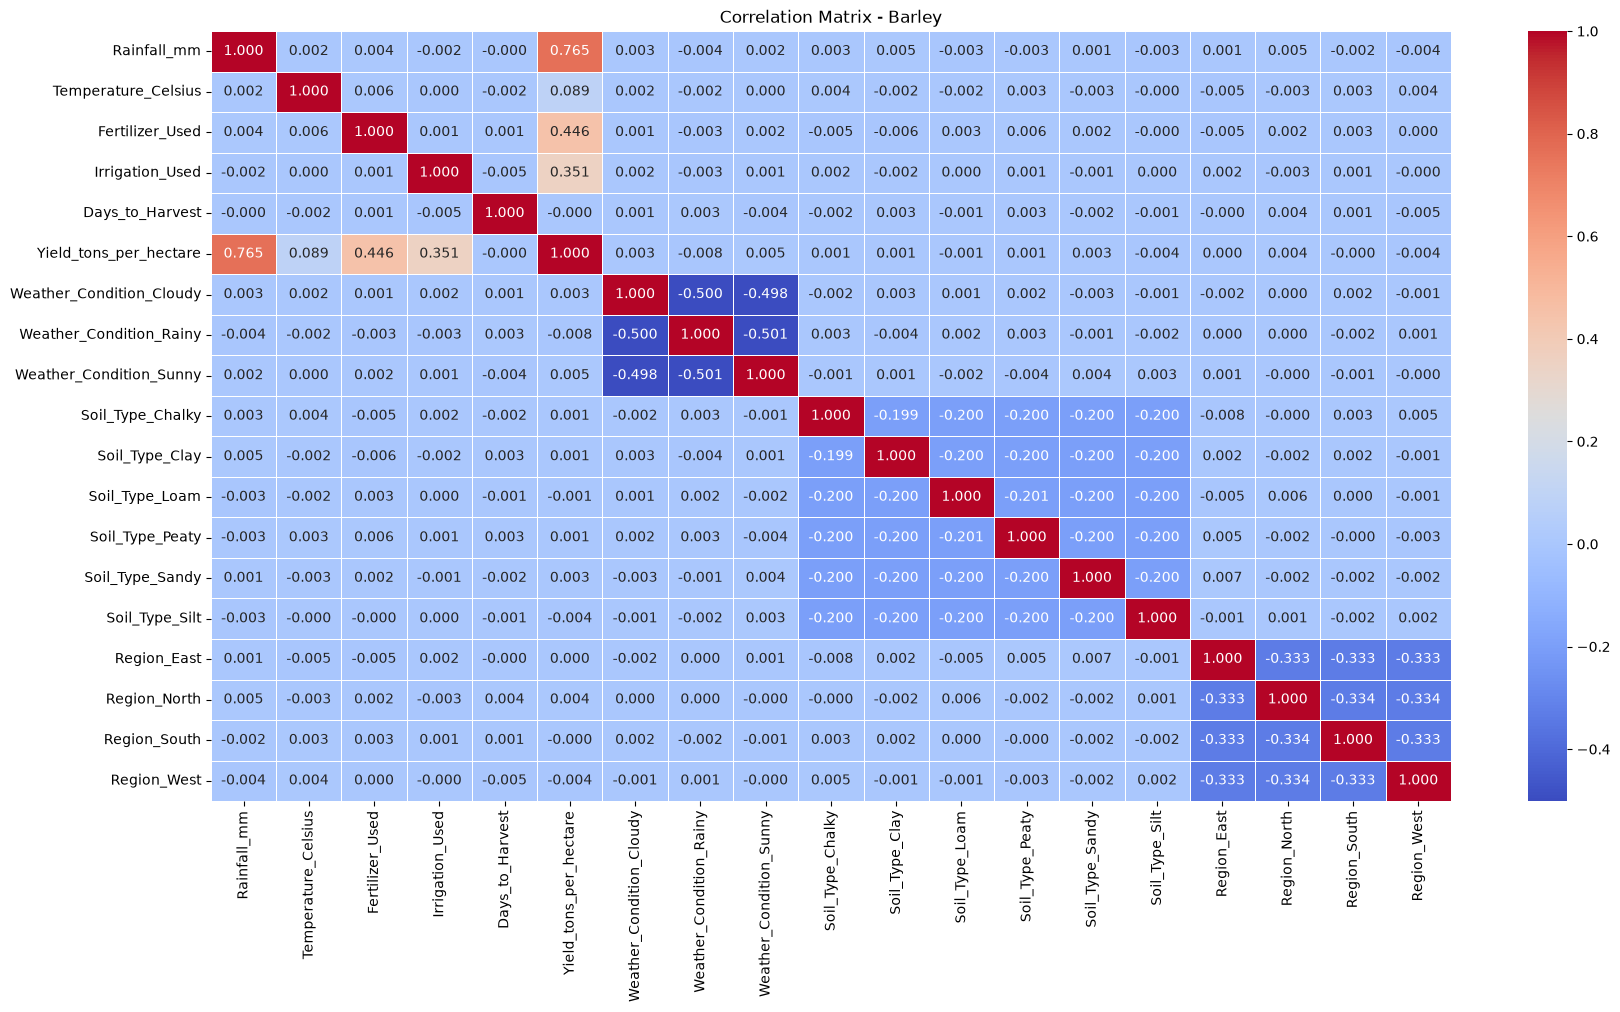

In [139]:
# Confusion Matrix
plt.figure(figsize=(20,10))
sns.heatmap(data=data.corr(), annot=True, cmap='coolwarm', linewidths=.5, fmt=".3f")
plt.title(f'Correlation Matrix - {target}')
plt.show()

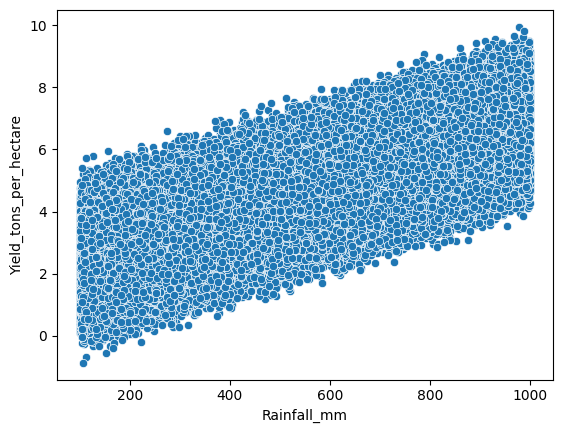

In [ ]:
sns.scatterplot(data=data, x='Rainfall_mm', y='Yield_tons_per_hectare')
plt.show()

# Modelos preliminares

In [140]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV

In [141]:
# Elegir variable de predicción
X = data.drop(columns=['Yield_tons_per_hectare'])
y = data.Yield_tons_per_hectare
X.shape, y.shape

((166777, 18), (166777,))

In [142]:
# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.54586348,  0.31769805, -0.99852008, ...,  1.72978974,
        -0.57744028, -0.57744951],
       [ 1.46116989,  0.30152475, -0.99852008, ..., -0.57810494,
        -0.57744028, -0.57744951],
       [ 0.27800858, -0.09112141,  1.00148212, ...,  1.72978974,
        -0.57744028, -0.57744951],
       ...,
       [-0.5972604 , -0.72894278, -0.99852008, ..., -0.57810494,
        -0.57744028, -0.57744951],
       [-1.39688049, -0.35669632, -0.99852008, ...,  1.72978974,
        -0.57744028, -0.57744951],
       [ 1.47605885,  1.68469183,  1.00148212, ..., -0.57810494,
         1.73178083, -0.57744951]], shape=(166777, 18))

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
#mostrar resultados
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R2: {r2}, RMSE: {rmse}")

R2: 0.9134739069405501, RMSE: 0.49921048586255634


ValueError: Per-column arrays must each be 1-dimensional

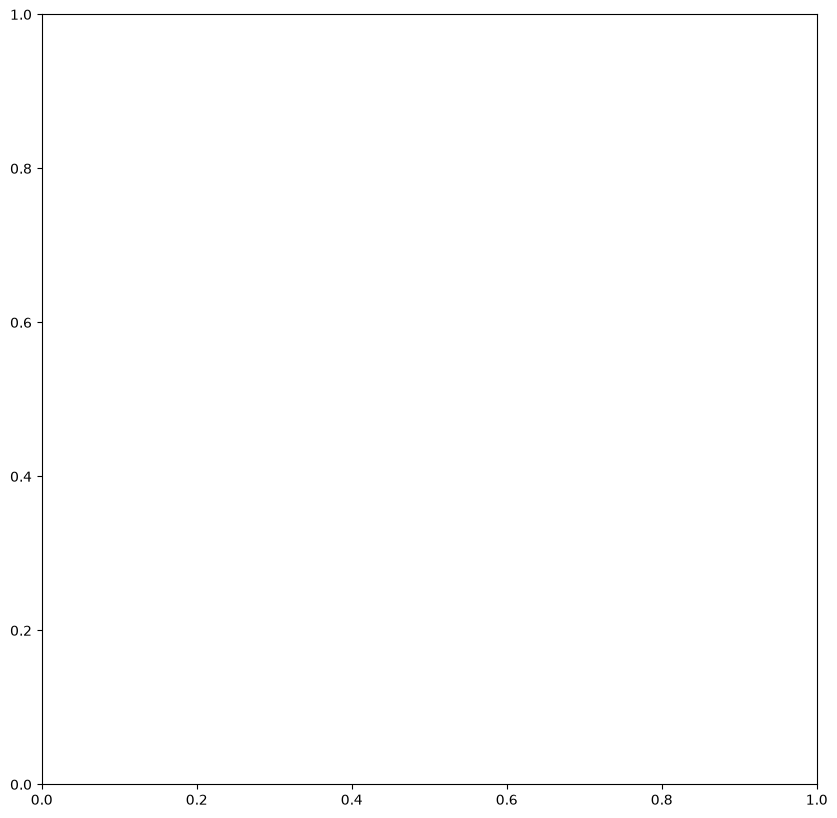

In [147]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.scatterplot(x = y_test, y = y_pred, alpha=0.6, hue=X_test)
ax.set_xlabel("Yield (tons per hectare)")
ax.set_ylabel("Predicted Yield (tons per hectare)")
ax.set_title(f"Real vs predicted Yield\nr2: {round(r2, 3)}\nrmse: {round(rmse, 3)}")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.plot([0, 100], [0, 100], "--", color="red")
ax.legend([])
plt.show()

### Modelo 2

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet

In [43]:
X = data[num_features].drop(columns=['Yield_tons_per_hectare'])
y = data.Yield_tons_per_hectare
X.shape, y.shape


((166824, 3), (166824,))

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42) #Dividir en entrenamiento y testing
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((125118, 3), (41706, 3), (125118,), (41706,))

In [45]:
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures()),
        ("model", ElasticNet())
    ]
)

params = {
    "poly__degree": [1, 2, 3],
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
grid_search = GridSearchCV(pipeline, params, cv=5)
grid_search.fit(X_train, y_train)
display(grid_search.best_params_)
display(grid_search.best_score_)
pipeline = grid_search.best_estimator_

{'model__alpha': 0.01, 'model__l1_ratio': 0.1, 'poly__degree': 1}

np.float64(0.5908716857554716)

In [ ]:
pipeline

,steps,"[('scaler', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,1
,interaction_only,False
,include_bias,True
,order,'C'
